# 📊 Notebook 04 — Master Leakage Consolidation & KPI Summary

---

## 🏢 Business Context

Individual leakage analyses — no matter how rigorous — have limited strategic value in isolation. A business needs a unified, executive-readable view that answers a single question: *"Across all our known leakage channels, how much revenue are we losing, where is it coming from, and what should we fix first?"*

This notebook serves as the **consolidation layer** of the Revenue Leakage Intelligence System. It pulls all three upstream analytical tables from a centralised SQLite database, aggregates total leakage, classifies each leakage type by business severity, assigns recovery timelines, and produces the master KPI summary that powers the executive dashboard in Power BI.

---

## ❗ Business Problem Statement

> *"The business has completed individual investigations into discount abuse, pricing gaps, billing reconciliation failures, and return behaviour. However, there is no consolidated view that shows total organisational leakage, compares the relative scale of each problem, or guides prioritisation of remediation efforts. Leadership needs a single, actionable summary to allocate recovery resources."*

**Core questions this notebook answers:**
1. What is the total revenue leakage across all four identified leakage types?
2. What percentage of total leakage does each type contribute?
3. Which leakage types are most critical and require immediate structural intervention?
4. What is a realistic recovery timeline for each leakage type?
5. How should the business prioritise its remediation efforts?

---

## 🎯 Objectives

| # | Objective | Type |
|---|---|---|
| 1 | Load all three analytical tables from SQLite into a single session | Data Engineering |
| 2 | Extract the total leakage amount for each of the four leakage types | Aggregation |
| 3 | Compute contribution % of each leakage type to total leakage | KPI Calculation |
| 4 | Classify leakage types by severity based on contribution thresholds | Classification |
| 5 | Assign recovery category and timeline to each leakage type | Business Logic |
| 6 | Build and store the master KPI summary table in SQLite | Data Engineering |
| 7 | Export all four processed tables as CSVs for Power BI consumption | Deliverable |

---

## 📂 Input Tables

> **Prerequisite:** Notebooks 01, 02, and 03 must be fully executed before running this notebook. All three tables below are created by those notebooks and stored in the shared SQLite database.

| Table | Created By | Leakage Type Extracted |
|---|---|---|
| `superstore_analysis` | Notebook 01 | Discount Leakage + Pricing Leakage |
| `olist_billing_analysis` | Notebook 02 | Billing Leakage |
| `uci_customer_return_analysis` | Notebook 03 | Returns Leakage |

**Database path:** `../Database/revenue_leakage.db`

---

## 🔬 Methodology

```
SQLITE DATABASE
    │
    ▼
LOAD 3 TABLES       → superstore_df, olist_df, uci_df
    │
    ▼
LEAKAGE EXTRACTION
    discount_leakage = SUM(Discount Abuse Amount)   [superstore_df]
    pricing_leakage  = SUM(Pricing Leakage Amount)  [superstore_df]
    billing_leakage  = SUM(Billing Leakage Amount)  [olist_df, filtered > $1]
    returns_leakage  = SUM(Return Amount)            [uci_df]
    total_leakage    = sum of all four
    │
    ▼
KPI SUMMARY TABLE   → 4-row DataFrame
                       [Leakage Type | Leakage Amount | Contribution %]
    │
    ▼
SEVERITY CLASSIFICATION
    Contribution % < 10%      → Low
    Contribution % 10% – 30%  → Medium
    Contribution % ≥ 30%      → Critical
    │
    ▼
RECOVERY MAPPING
    Billing Leakage  → Recoverable (0–3 Months)
    Discount Leakage → Recoverable (0–3 Months)
    Pricing Leakage  → Process Fix (3–6 Months)
    Returns Leakage  → Structural  (6–12 Months)
    │
    ▼
SQLITE STORE        → Table: master_kpi_summary → revenue_leakage.db
    │
    ▼
CSV EXPORT          → 4 processed CSVs → Data/Processed_Data/
```

---

## 📏 Scope

**In Scope:**
- Consolidation of the four leakage types identified in Notebooks 01–03
- KPI summary construction for executive and Power BI dashboard consumption
- Severity classification and recovery timeline assignment
- Full CSV export of all processed tables

**Out of Scope:**
- Any new exploratory analysis or feature engineering (all upstream work is complete by this stage)
- Addition of new leakage types not covered in Notebooks 01–03
- Predictive modelling or forecasting of future leakage trajectories

---

## 📤 Deliverables

| Deliverable | Format | Destination |
|---|---|---|
| `master_kpi_summary` | SQLite table | `revenue_leakage.db` |
| `master_kpi_summary.csv` | CSV | `Data/Processed_Data/` |
| `superstore_analysis.csv` | CSV | `Data/Processed_Data/` |
| `olist_billing_analysis.csv` | CSV | `Data/Processed_Data/` |
| `uci_customer_return_analysis.csv` | CSV | `Data/Processed_Data/` |

---

## ⚠️ Assumptions & Limitations

| # | Assumption / Limitation |
|---|---|
| 1 | The consolidated $1.61M total aggregates values from three different currencies (USD, BRL, GBP) and three different business contexts — it is a conceptual framework total, not a single-entity P&L figure |
| 2 | Severity thresholds (10% / 30%) are based on contribution share, not absolute dollar value — the same percentages may carry different urgency depending on business scale |
| 3 | Recovery timelines (0–3, 3–6, 6–12 months) are business-convention estimates based on the type of organisational change required, not guaranteed remediation windows |
| 4 | This notebook does not re-validate upstream logic — it trusts the outputs of Notebooks 01, 02, and 03 as-is |

---

## 📋 Notebook Structure

1. Library Imports & Setup
2. SQLite Connection & Table Verification
3. Load All Three Analytical Tables
4. Leakage Amount Extraction (per type)
5. Total Leakage Calculation
6. KPI Summary Table Construction
7. Contribution % Calculation
8. Severity Classification
9. Recovery Category Mapping
10. Master KPI Table — SQLite Storage
11. Pie Chart — Leakage Contribution Breakdown
12. CSV Export (all 4 tables)

---

| | |
|---|---|
| **Author** | Abhiram |
| **Project** | Revenue Leakage Intelligence System |
| **Notebook** | 04 of 04 — Final Consolidation |
| **Input Tables** | `superstore_analysis`, `olist_billing_analysis`, `uci_customer_return_analysis` |
| **Output Table** | `master_kpi_summary` → `revenue_leakage.db` |
| **Output CSVs** | All 4 tables → `Data/Processed_Data/` |

In [1]:
# ==============================
# IMPORT LIBRARIES
# ==============================

import pandas as pd
import numpy as np

import sqlite3

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# ==============================
# SQLITE CONNECTION
# ==============================

conn = sqlite3.connect(
    "../Database/revenue_leakage.db"
)

print("Connected to SQLite.")

Connected to SQLite.


In [3]:
# ==============================
# CHECK AVAILABLE TABLES
# ==============================

query = """
SELECT name
FROM sqlite_master
WHERE type='table'
"""

pd.read_sql(query, conn)

,name
0,uci_customer_return_analysis
1,olist_billing_analysis
2,superstore_analysis
3,master_kpi_summary


In [4]:
# ==============================
# LOAD TABLES FROM SQLITE
# ==============================

superstore_df = pd.read_sql("""
SELECT * FROM superstore_analysis
""", conn)

olist_df = pd.read_sql("""
SELECT * FROM olist_billing_analysis
""", conn)

uci_df = pd.read_sql("""
SELECT * FROM uci_customer_return_analysis
""", conn)

print("SUPERSTORE SHAPE :", superstore_df.shape)
print("OLIST SHAPE      :", olist_df.shape)
print("UCI SHAPE        :", uci_df.shape)

SUPERSTORE SHAPE : (9994, 30)
OLIST SHAPE      : (99441, 18)
UCI SHAPE        : (5881, 6)


In [5]:
# ==============================
# SUPERSTORE LEAKAGE
# ==============================

discount_leakage = superstore_df[
    superstore_df["Discount Abuse Amount"] > 0
]["Discount Abuse Amount"].sum()

pricing_leakage = superstore_df[
    superstore_df["Pricing Leakage Amount"] > 0
]["Pricing Leakage Amount"].sum()


# ==============================
# OLIST BILLING LEAKAGE
# ==============================

billing_leakage = olist_df[
    olist_df["Billing Leakage Amount"] > 1
]["Billing Leakage Amount"].sum()


# ==============================
# UCI RETURNS LEAKAGE
# ==============================

returns_leakage = uci_df[
    uci_df["Return Amount"] > 0
]["Return Amount"].sum()


# ==============================
# TOTAL LEAKAGE
# ==============================

total_leakage = (
    discount_leakage
    + pricing_leakage
    + billing_leakage
    + returns_leakage
)

print("DISCOUNT LEAKAGE :", round(discount_leakage, 2))
print("PRICING LEAKAGE  :", round(pricing_leakage, 2))
print("BILLING LEAKAGE  :", round(billing_leakage, 2))
print("RETURNS LEAKAGE  :", round(returns_leakage, 2))

print("\nTOTAL LEAKAGE :", round(total_leakage, 2))

DISCOUNT LEAKAGE : 138515.24
PRICING LEAKAGE  : 440380.54
BILLING LEAKAGE  : 341.03
RETURNS LEAKAGE  : 1034085.87

TOTAL LEAKAGE : 1613322.68


In [6]:
# ==============================
# CREATE KPI SUMMARY TABLE
# ==============================

kpi_summary = pd.DataFrame({

    "Leakage Type": [
        "Discount Leakage",
        "Pricing Leakage",
        "Billing Leakage",
        "Returns Leakage"
    ],

    "Leakage Amount": [
        discount_leakage,
        pricing_leakage,
        billing_leakage,
        returns_leakage
    ]

})


# ==============================
# PERCENTAGE CONTRIBUTION
# ==============================

kpi_summary["Contribution %"] = (
    kpi_summary["Leakage Amount"]
    / total_leakage
) * 100


# ==============================
# ROUND VALUES
# ==============================

kpi_summary["Leakage Amount"] = (
    kpi_summary["Leakage Amount"]
    .round(2)
)

kpi_summary["Contribution %"] = (
    kpi_summary["Contribution %"]
    .round(2)
)


# ==============================
# SORT DESCENDING
# ==============================

kpi_summary = kpi_summary.sort_values(
    by="Leakage Amount",
    ascending=False
)


# ==============================
# DISPLAY
# ==============================

kpi_summary

,Leakage Type,Leakage Amount,Contribution %
3,Returns Leakage,1034085.87,64.10
1,Pricing Leakage,440380.54,27.30
0,Discount Leakage,138515.24,8.59
2,Billing Leakage,341.03,0.02


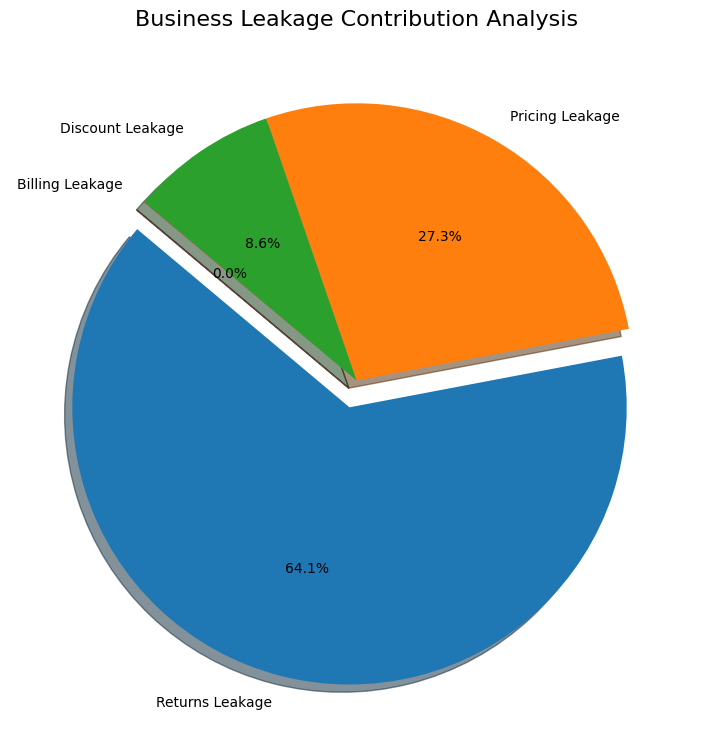

In [7]:
# ==============================
# PROFESSIONAL PIE CHART
# ==============================

plt.figure(figsize=(9, 9))

explode = [0.1, 0, 0, 0]

plt.pie(
    kpi_summary["Contribution %"],
    
    labels=kpi_summary["Leakage Type"],
    
    autopct="%1.1f%%",
    
    startangle=140,
    
    explode=explode,
    
    shadow=True
)

plt.title(
    "Business Leakage Contribution Analysis",
    fontsize=16
)

plt.show()

In [8]:
# ==============================
# LEAKAGE SEVERITY CLASSIFICATION
# ==============================

conditions = [

    kpi_summary["Contribution %"] < 10,

    (
        (kpi_summary["Contribution %"] >= 10)
        &
        (kpi_summary["Contribution %"] < 30)
    ),

    kpi_summary["Contribution %"] >= 30
]


severity = [
    "Low",
    "Medium",
    "Critical"
]


kpi_summary["Severity"] = np.select(
    conditions,
    severity,
    default="Unknown"
)


kpi_summary

,Leakage Type,Leakage Amount,Contribution %,Severity
3,Returns Leakage,1034085.87,64.10,Critical
1,Pricing Leakage,440380.54,27.30,Medium
0,Discount Leakage,138515.24,8.59,Low
2,Billing Leakage,341.03,0.02,Low


In [9]:

# ==============================
# EXECUTIVE LEAKAGE CLASSIFICATION
#| Leakage Type     | Classification |
#| ---------------- | -------------- |
#| Billing Leakage  | Recoverable    |
#| Discount Leakage | Recoverable    |
#| Pricing Leakage  | Process Fix    |
#| Returns Leakage  | Structural     |

# ==============================

recovery_map = {

    "Billing Leakage": "Recoverable (0-3 Months)",

    "Discount Leakage": "Recoverable (0-3 Months)",

    "Pricing Leakage": "Process Fix (3-6 Months)",

    "Returns Leakage": "Structural (6-12 Months)"
}


# ==============================
# MAP CLASSIFICATION
# ==============================

kpi_summary["Recovery Category"] = (
    kpi_summary["Leakage Type"]
    .map(recovery_map)
)


# ==============================
# DISPLAY
# ==============================

kpi_summary

,Leakage Type,Leakage Amount,Contribution %,Severity,Recovery Category
3,Returns Leakage,1034085.87,64.10,Critical,Structural (6-12 Months)
1,Pricing Leakage,440380.54,27.30,Medium,Process Fix (3-6 Months)
0,Discount Leakage,138515.24,8.59,Low,Recoverable (0-3 Months)
2,Billing Leakage,341.03,0.02,Low,Recoverable (0-3 Months)


In [10]:
# ==============================
# STORE KPI SUMMARY TABLE
# ==============================

kpi_summary.to_sql(

    "master_kpi_summary",

    conn,

    if_exists="replace",

    index=False

)

print("KPI Summary Table Stored Successfully.")

KPI Summary Table Stored Successfully.


In [11]:
kpi_summary.head()

,Leakage Type,Leakage Amount,Contribution %,Severity,Recovery Category
3,Returns Leakage,1034085.87,64.10,Critical,Structural (6-12 Months)
1,Pricing Leakage,440380.54,27.30,Medium,Process Fix (3-6 Months)
0,Discount Leakage,138515.24,8.59,Low,Recoverable (0-3 Months)
2,Billing Leakage,341.03,0.02,Low,Recoverable (0-3 Months)


In [15]:
# ==============================
# EXPORT TABLES TO CSV
# ==============================

superstore_df.to_csv(
    "../Data/Processed_Data/superstore_analysis.csv",
    index=False
)

olist_df.to_csv(
    "../Data/Processed_Data/olist_billing_analysis.csv",
    index=False
)

uci_df.to_csv(
    "../Data/Processed_Data/uci_customer_return_analysis.csv",
    index=False
)

kpi_summary.to_csv(
    "../Data/Processed_Data/master_kpi_summary.csv",
    index=False
)


print("All processed CSV files exported successfully.")

All processed CSV files exported successfully.
